# 적분의 욕망과 미적분학의 기본정리 (4기 영상)-11강 4기 26강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.symbols("x", real=True)

## 0. 일변수 미분 — 의미는 잠시 미루고 정의(룰)부터
강의에서 손에 익힌 미분 룰들을 SymPy로 그대로 검산합니다.
$x^\alpha\to\alpha x^{\alpha-1}$, $(\sin x)'=\cos x$, $(e^{2x})'=2e^{2x}$,
그리고 라이프니츠 곱미분 $(e^{2x}\sin x)'$, $x\ln x$.

In [2]:
funcs = [
    x**sp.Rational(5, 2),      # x^alpha  -> alpha x^(alpha-1)
    sp.sin(x),                 # cos x
    sp.cos(x),                 # -sin x
    sp.exp(2 * x),             # 2 e^{2x}
    1 / x,                     # -1/x^2
    3 * sp.log(x),             # 3/x
    sp.exp(2 * x) * sp.sin(x), # 2 e^{2x} sin x + e^{2x} cos x  (Leibniz)
    x * sp.log(x),             # 1 + ln x
]
for f in funcs:
    print(f"d/dx [ {str(f):>16} ] = {sp.simplify(sp.diff(f, x))}")

d/dx [         x**(5/2) ] = 5*x**(3/2)/2
d/dx [           sin(x) ] = cos(x)
d/dx [           cos(x) ] = -sin(x)
d/dx [         exp(2*x) ] = 2*exp(2*x)
d/dx [              1/x ] = -1/x**2
d/dx [         3*log(x) ] = 3/x
d/dx [  exp(2*x)*sin(x) ] = (2*sin(x) + cos(x))*exp(2*x)
d/dx [         x*log(x) ] = log(x) + 1


## 6. 가우스의 1부터 100까지, 그리고 망원경 합
가우스의 $1+2+\cdots+100=5050$ 을 페어링으로, 그리고 망원경 합
$10-1=(10-9)+(9-8)+\cdots+(2-1)$ 으로 풀어 "각 항을 계산하지 않고 개수만 센다"를 확인합니다.

In [3]:
N = 100
brute = sum(range(1, N + 1))
gauss = (N + 1) * (N // 2)                       # pair (1,100),(2,99),... -> 101 x 50
print(f"1+2+...+{N}: brute={brute}, gauss pairing (N+1)*(N/2)={gauss}")

# telescoping 10 - 1, with arbitrary (uneven) cut points -> still cancels
cuts = [10, 9.5, 8, 7.3, 6, 6, 3, 2, 1]          # uneven on purpose; endpoints 10 and 1
terms = [cuts[i] - cuts[i + 1] for i in range(len(cuts) - 1)]
print("telescoping terms :", terms)
print("sum of terms      :", round(sum(terms), 6), " ==  10 - 1 =", 10 - 1)

1+2+...+100: brute=5050, gauss pairing (N+1)*(N/2)=5050
telescoping terms : [0.5, 1.5, 0.7000000000000002, 1.2999999999999998, 0, 3, 1, 1]
sum of terms      : 9.0  ==  10 - 1 = 9


## 7. 미분가능한 함수에 적용 — 미적분학의 기본정리
망원경 합 $f(b)-f(a)=\sum_k\big(f(x_k)-f(x_{k-1})\big)$ 에서 간격을 줄이면
$\sum_k f'(x_{k-1})\,\Delta x\to\int_a^b f'(x)\,dx = f(b)-f(a)$.
구체 함수 $f(x)=\tfrac13 x^3-x$ (그러면 $f'(x)=x^2-1$) 로 양변을 직접 비교합니다.

In [4]:
f = sp.Rational(1, 3) * x**3 - x
fp = sp.diff(f, x)
a_sym, b_sym = sp.Integer(1), sp.Integer(4)
lhs = sp.integrate(fp, (x, a_sym, b_sym))        # int_a^b f'(x) dx
rhs = f.subs(x, b_sym) - f.subs(x, a_sym)        # f(b) - f(a)
print("f(x)  =", f)
print("f'(x) =", fp)
print(f"int_{{{a_sym}}}^{{{b_sym}}} f'(x) dx =", lhs)
print(f"f({b_sym}) - f({a_sym})              =", rhs, "  (FTC: equal)" )

# telescoping sum converging to the integral as the partition refines
fl = sp.lambdify(x, f, "numpy")
fpl = sp.lambdify(x, fp, "numpy")
a, b = 1.0, 4.0
exact = float(rhs)
print("\n  n      telescoping sum f(b)-f(a)      Riemann sum  sum f'(x_k) dx")
for n in [1, 2, 5, 20, 200, 2000]:
    xs = np.linspace(a, b, n + 1)
    tele = np.sum(fl(xs[1:]) - fl(xs[:-1]))      # telescopes exactly -> f(b)-f(a)
    riem = np.sum(fpl(xs[:-1]) * np.diff(xs))    # left Riemann sum of f'  -> integral
    print(f"{n:5d}      {tele:10.6f}                     {riem:10.6f}")
print(f"exact  int f' = f(b)-f(a) = {exact:.6f}")

f(x)  = x**3/3 - x
f'(x) = x**2 - 1
int_{1}^{4} f'(x) dx = 18
f(4) - f(1)              = 18   (FTC: equal)

  n      telescoping sum f(b)-f(a)      Riemann sum  sum f'(x_k) dx
    1       18.000000                       0.000000
    2       18.000000                       7.875000
    5       18.000000                      13.680000
   20       18.000000                      16.886250
  200       18.000000                      17.887612
 2000       18.000000                      17.988751
exact  int f' = f(b)-f(a) = 18.000000


### 그림: 망원경 합 → 정적분
왼쪽: $f$ 위의 망원경 막대 $f(x_k)-f(x_{k-1})$ 가 쌓여 $f(b)-f(a)$.
오른쪽: 같은 칸에서 리만 합 $\sum f'(x_{k-1})\Delta x$ 가 $\int_a^b f'(x)\,dx$ 에 수렴.

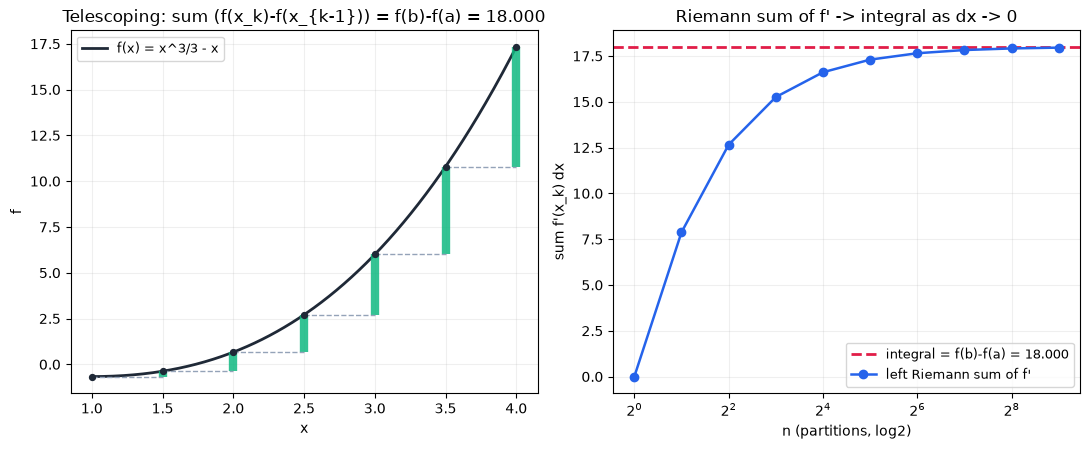

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.6))

# Left: telescoping bars on f
n = 6
xs = np.linspace(a, b, n + 1)
xfine = np.linspace(a, b, 400)
axL.plot(xfine, fl(xfine), color="#1f2937", lw=2, label="f(x) = x^3/3 - x")
for i in range(n):
    x0, x1 = xs[i], xs[i + 1]
    y0, y1 = fl(x0), fl(x1)
    axL.plot([x1, x1], [y0, y1], color="#10b981", lw=6, solid_capstyle="butt", alpha=.85)
    axL.plot([x0, x1], [y0, y0], color="#94a3b8", lw=1, ls="--")
axL.scatter(xs, fl(xs), color="#1f2937", s=18, zorder=5)
axL.set_title(f"Telescoping: sum (f(x_k)-f(x_{{k-1}})) = f(b)-f(a) = {exact:.3f}")
axL.set_xlabel("x"); axL.set_ylabel("f")
axL.legend(loc="upper left", fontsize=9); axL.grid(alpha=.2)

# Right: convergence of Riemann sum to the integral
ns = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512])
sums = []
for nn in ns:
    xss = np.linspace(a, b, nn + 1)
    sums.append(np.sum(fpl(xss[:-1]) * np.diff(xss)))
axR.axhline(exact, color="#e11d48", lw=2, ls="--", label=f"integral = f(b)-f(a) = {exact:.3f}")
axR.plot(ns, sums, "o-", color="#2563eb", lw=1.8, label="left Riemann sum of f'")
axR.set_xscale("log", base=2)
axR.set_title("Riemann sum of f' -> integral as dx -> 0")
axR.set_xlabel("n (partitions, log2)"); axR.set_ylabel("sum f'(x_k) dx")
axR.legend(fontsize=9); axR.grid(alpha=.2)

fig.tight_layout()
plt.show()